<a href="https://colab.research.google.com/github/karmagodjs/ai-ml-projects-small/blob/main/01_house_price_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Step 1: Libraries Import

In [1]:
import pandas as pd  # data handling ke liye pandas import kar rahe
import numpy as np  # numerical operations ke liye numpy import kar rahe
import matplotlib.pyplot as plt  # plotting ke liye matplotlib
import seaborn as sns  # better visualizations ke liye seaborn
from sklearn.model_selection import train_test_split  # data split ke liye
from sklearn.preprocessing import StandardScaler  # scaling ke liye
from sklearn.linear_model import LinearRegression, Ridge, Lasso  # linear models
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor  # tree-based models
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score  # evaluation metrics
import joblib  # model save/load ke liye
import os  # folder banane ke liye
import warnings  # warnings handle karne ke liye
warnings.filterwarnings("ignore")  # unnecessary warnings ignore kar rahe hain

%matplotlib inline
# ^ ye line notebook mein plots ko inline (cell ke neeche) dikhane ke liye hai

## Step 2: Data Load Karna

In [3]:
train = pd.read_csv("train.csv")  # training dataset load kar rahe hain
test = pd.read_csv("test.csv")  # test dataset load kar rahe hain

print("Train shape:", train.shape)  # (rows, columns) dikhayega, jaise (1460, 81)
print("Test shape:", test.shape)  # test mein SalePrice column nahi hoga, isliye ek column kam

Train shape: (1460, 81)
Test shape: (1459, 80)


## Step 3: Basic Exploration

In [4]:
train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [5]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [6]:
train["SalePrice"].describe()

,SalePrice
count,1460.000000
mean,180921.195890
std,79442.502883
min,34900.000000
25%,129975.000000
50%,163000.000000
75%,214000.000000
max,755000.000000


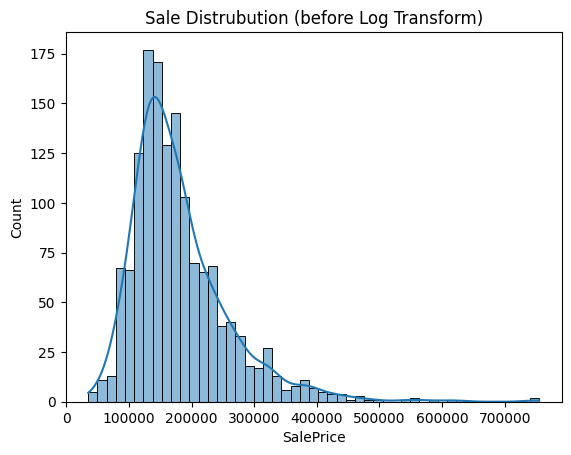

In [7]:
sns.histplot(train["SalePrice"], kde=True)
plt.title("Sale Distrubution (before Log Transform)")
plt.show()

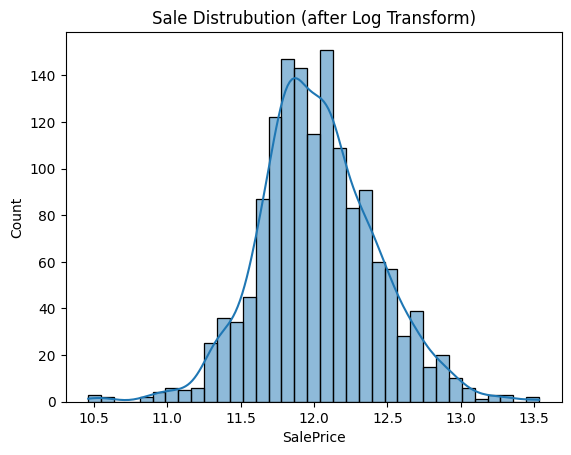

In [8]:
train["SalePrice"] = np.log1p(train["SalePrice"])
sns.histplot(train["SalePrice"], kde=True)
plt.title("Sale Distrubution (after Log Transform)")
plt.show()

## Step 4: Missing Values Check

In [10]:
missing = train.isnull().sum().sort_values(ascending = False)
missing_percent = (missing/len(train))*100

missing_df = pd.DataFrame({"missing": missing, "Percent": missing_percent})
missing_df[missing_df["missing"]>0]

,missing,Percent
PoolQC,1453,99.520548
MiscFeature,1406,96.301370
Alley,1369,93.767123
Fence,1179,80.753425
MasVnrType,872,59.726027
FireplaceQu,690,47.260274
LotFrontage,259,17.739726
GarageQual,81,5.547945
GarageFinish,81,5.547945
GarageType,81,5.547945


## Step 5: Data Cleaning

In [14]:
train_id = train["Id"]
test_id = test["Id"]
y = train["SalePrice"]

train_features = train.drop(["Id", "SalePrice"], axis=1)
test_features = test.drop(["Id"], axis=1)
all_data = pd.concat([train_features, test_features], axis = 0)
all_data.shape


(2919, 79)

In [21]:
from numpy._core import numeric
none_cols = ["PoolQC", "MiscFeature", "Alley", "Fence", "FireplaceQu",
             "GarageType", "GarageFinish", "GarageQual", "GarageCond",
             "BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1",
             "BsmtFinType2", "MasVnrType"]

for col in none_cols:
    all_data[col] = all_data[col].fillna("None")

zero_cols = ["GarageYrBlt", "GarageArea", "GarageCars",
             "BsmtFinSF1", "BsmtFinSF2", "BsmtUnfSF", "TotalBsmtSF",
             "BsmtFullBath", "BsmtHalfBath", "MasVnrArea"]

for col in zero_cols:
  all_data[col] = all_data[col].fillna(0)

all_data["LotFrontage"] = all_data.groupby("Neighborhood")["LotFrontage"].transform(lambda x: x.fillna(x.median()))

categorical_cols = all_data.select_dtypes(include="object").columns
for col in categorical_cols:
  if all_data[col].isnull().sum()>0:
    all_data[col]= all_data[col].fillna(all_data[col].mode()[0])

numeric_cols = all_data.select_dtypes(include=np.number).columns
for col in numeric_cols:
  if all_data[col].isnull().sum()>0:
    all_data[col] = all_data[col].fillna(all_data[col].median())

print("Total missing after clean:", all_data.isnull().sum().sum())

Total missing after clean: 0


In [22]:
all_data.isnull().sum().sum()

np.int64(0)

## Step 6: Feature Engineering

In [24]:
all_data["TotalSF"] = all_data["TotalBsmtSF"]+all_data["1stFlrSF"] + all_data["2ndFlrSF"]
all_data["HouseAge"] = all_data["YrSold"] - all_data["YearBuilt"]
all_data["RemodAge"] = all_data["YrSold"] - all_data["YearRemodAdd"]
all_data["TotalBath"] = (all_data["FullBath"] + 0.5*all_data["HalfBath"] +
                         all_data["BsmtFullBath"] + 0.5*all_data["BsmtHalfBath"])


all_data["IsRemodeled"] = (all_data["YearBuilt"] != all_data["YearRemodAdd"]).astype(int)
all_data["HasPool"] = (all_data["PoolArea"] > 0).astype(int)
all_data["HasGarage"] = (all_data["GarageArea"] > 0).astype(int)
all_data["HasFireplace"] = (all_data["Fireplaces"] > 0).astype(int)
all_data["Has2ndFloor"] = (all_data["2ndFlrSF"] > 0).astype(int)
all_data["MSSubClass"] = all_data["MSSubClass"].astype(str)

all_data[["TotalSF", "HouseAge", "TotalBath", "HasPool", "HasGarage"]].head()

,TotalSF,HouseAge,TotalBath,HasPool,HasGarage
0,2566.0,5,3.5,0,1
1,2524.0,31,2.5,0,1
2,2706.0,7,3.5,0,1
3,2473.0,91,2.0,0,1
4,3343.0,8,3.5,0,1


## Step 7: Encoding Categorical Variables

In [27]:
all_data = pd.get_dummies(all_data, drop_first = True) #One-Hot Encoding #One-hot encoding is a technique used to convert categorical data (like "red", "blue", "green") into a numerical format that machine learning algorithms can understand.
all_data.shape

(2919, 282)

## Step 8: Train-Test Split Wapas Karna Aur Validation Set Banana

In [29]:
X = all_data.iloc[:len(train_features), :]
X_test_final = all_data.iloc[len(train_features):, :]

print("X (train Features) shape:", X.shape)
print("X test Final shape:", X_test_final.shape)


X (train Features) shape: (1460, 282)
X test Final shape: (1459, 282)


In [31]:
X_train, X_vali, y_train, y_vali = train_test_split(X, y, test_size=0.2, random_state=42)

print("X train shape:", X_train.shape)
print("X vali shape:", X_vali.shape)
print("y train shape:", y_train.shape)
print("y vali shape:", y_vali.shape)

X train shape: (1168, 282)
X vali shape: (292, 282)
y train shape: (1168,)
y vali shape: (292,)


## Step 9: Feature Scaling

In [32]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_vali_scaled = scaler.transform(X_vali)
X_test_final_scaled = scaler.transform(X_test_final)

X_train_scaled[:5]

array([[-0.01933867, -0.21289571, -0.82044456, ..., -0.12510865,
         0.46001984, -0.30263639],
       [-0.50039047, -0.26524463, -0.08893368, ..., -0.12510865,
         0.46001984, -0.30263639],
       [-0.15053462, -0.17784146, -0.82044456, ..., -0.12510865,
         0.46001984, -0.30263639],
       [-0.45665849, -0.32447422, -0.82044456, ..., -0.12510865,
         0.46001984, -0.30263639],
       [-0.89397831, -0.52903482, -0.82044456, ..., -0.12510865,
         0.46001984, -0.30263639]])

## Step 10: Model Training Function

In [38]:
def evaluate_model(model, X_tr, y_tr, X_v, y_v, name):
    model.fit(X_tr, y_tr)
    preds = model.predict(X_v)
    rmse = np.sqrt(mean_squared_error(y_v, preds))
    mae = mean_absolute_error(y_v, preds)
    r2 = r2_score(y_v, preds)

    print(f"{name} -> RMSE: {rmse:.4f}, MAE: {mae:.4f}, R2: {r2:.4f}")
    return model, rmse

## Step 11: Multiple Models Train Karna

In [39]:
results = {}

lr = LinearRegression()
model_lr, rmse_lr = evaluate_model(lr, X_train_scaled, y_train, X_vali_scaled, y_vali, "Linear Regression")
results["Linear Regression"] = rmse_lr

Linear Regression -> RMSE: 0.1687, MAE: 0.0964, R2: 0.8475


In [40]:
ridge = Ridge()
model_ridge, rmse_ridge = evaluate_model(ridge, X_train_scaled, y_train, X_vali_scaled, y_vali, "Ridge Regression")
results["Ridge Regression"] = rmse_ridge

Ridge Regression -> RMSE: 0.1674, MAE: 0.0966, R2: 0.8498


In [41]:
lasso = Lasso(alpha=0.001)
model_lasso, rmse_lasso = evaluate_model(lasso, X_train_scaled, y_train, X_vali_scaled, y_vali, "Lasso Regression")
results["Lasso Regression"] = rmse_lasso

Lasso Regression -> RMSE: 0.1574, MAE: 0.0955, R2: 0.8672


In [42]:
rf = RandomForestRegressor(n_estimators=300, max_depth=15, random_state=42, n_jobs=-1)
model_rf, rmse_rf = evaluate_model(rf, X_train, y_train, X_vali, y_vali, "Random Forest")
results["Random Forest"] = rmse_rf

Random Forest -> RMSE: 0.1475, MAE: 0.0974, R2: 0.8833


In [43]:
gb = GradientBoostingRegressor(n_estimators=300, learning_rate=0.05, max_depth=3, random_state=42)
model_gb, rmse_gb = evaluate_model(gb, X_train, y_train, X_vali, y_vali, "Gradient Boosting")
results["Gradient Boosting"] = rmse_gb

Gradient Boosting -> RMSE: 0.1385, MAE: 0.0901, R2: 0.8972


## Step 12: Best Model Select Karna

Best Model: Gradient Boosting with RMSE: 0.1385


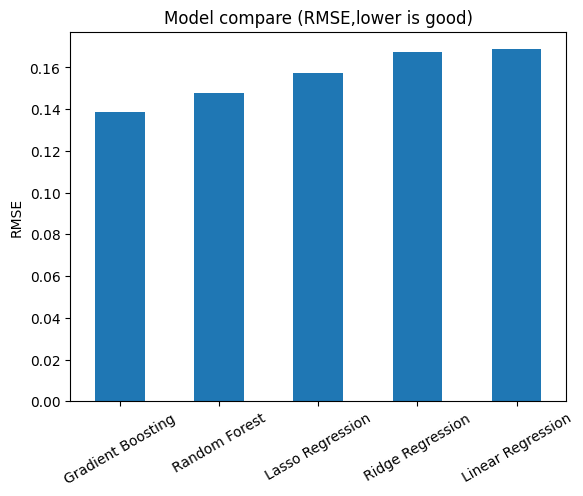

In [46]:
best_model_name = min(results, key=results.get)
print(f"Best Model: {best_model_name} with RMSE: {results[best_model_name]:.4f}")

pd.Series(results).sort_values().plot(kind = "bar", title = "Model compare (RMSE,lower is good)")
plt.ylabel("RMSE")
plt.xticks(rotation = 30)
plt.show()

## Step 13: Feature Importance (Random Forest se)

In [50]:
important = pd.Series(model_rf.feature_importances_, index=X.columns)
top_features = important.sort_values(ascending = False).head(15)

top_features

,0
OverallQual,0.390989
TotalSF,0.364911
GrLivArea,0.013566
LotArea,0.012161
GarageCars,0.012026
GarageArea,0.011935
CentralAir_Y,0.011741
TotalBath,0.011235
BsmtFinSF1,0.009319
RemodAge,0.009138


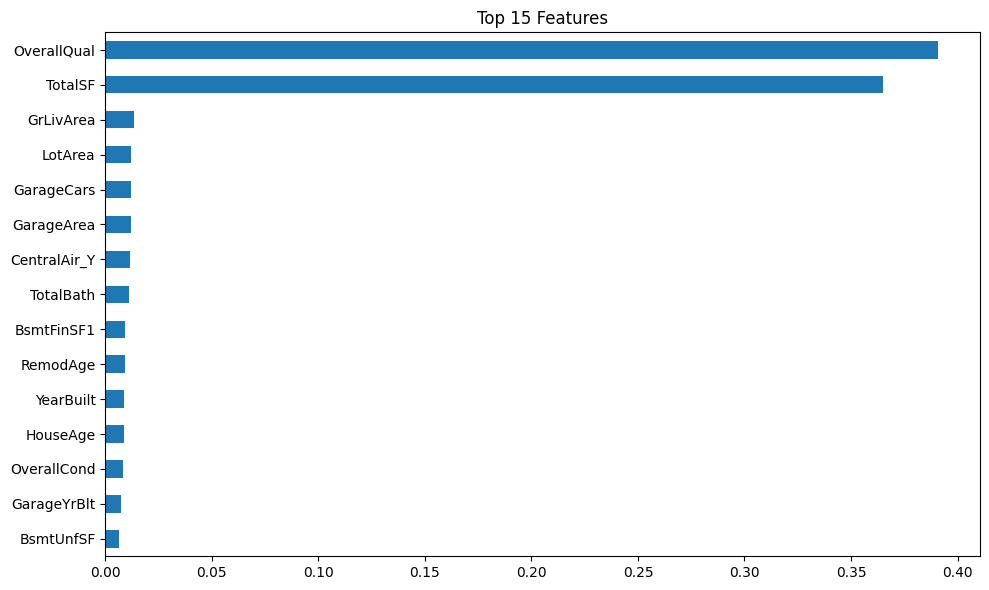

In [51]:
plt.figure(figsize = (10, 6))
top_features.plot(kind = "barh", title = "Top 15 Features")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Step 14: Final Prediction

In [52]:
finally_preds_log = model_gb.predict(X_test_final)
finally_preds = np.expm1(finally_preds_log)

submission = pd.DataFrame({"Id": test_id, "SalePrice": finally_preds})
submission.head()

,Id,SalePrice
0,1461,122749.949716
1,1462,162193.169362
2,1463,180246.418041
3,1464,186972.923925
4,1465,178132.698737


## Step 15: Best Model Save Karna (.pkl)

In [53]:
os.makedirs("models", exist_ok=True)
joblib.dump(model_gb, "models/best_model.pkl")
joblib.dump(scaler, "models/scaler.pkl")

print("models/best_model.pkl save")

models/best_model.pkl save
